<a href="https://colab.research.google.com/github/Vanessa049/Progetto_Parkinson/blob/main/HandPD_CNN_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HandPD – CNN 2D Baseline per Classificazione Parkinson vs Control

**Obiettivo:** classificazione binaria (sano vs. Parkinson) su immagini di spirali e meandri del dataset HandPD.

---

## Struttura Cartelle su Google Drive


```
MyDrive/
└── HandPD_Dataset/
    ├── SpiralControl/        ← immagini spirali soggetti sani
    ├── SpiralPatients/       ← immagini spirali pazienti Parkinson
    ├── MeanderControl/       ← immagini meandri soggetti sani
    ├── MeanderPatients/      ← immagini meandri pazienti Parkinson
    ├── Spiral_HandPD.csv     ← metadati spirali (opzionale)
    └── Meander_HandPD.csv    ← metadati meandri (opzionale)
```

**Nomenclatura immagini:** `XXXX-N.jpg` dove `XXXX` è l'ID paziente e `N` è il numero immagine (1-4 spirali, 5-8 meandri).

**Output del modello:** il file dei pesi (`baseline_cnn_best.pth`) verrà salvato automaticamente in `HandPD_Dataset/` su Drive.

---

In [1]:
# ─────────────────────────────────────────────────────────────
# CELLA 1 – Import e Setup
# ─────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Monta Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Percorso base del dataset su Drive
BASE_DIR = '/content/drive/MyDrive/HandPD_Dataset'

# Percorso dove salvare il modello migliore
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'baseline_cnn_best.pth')

print(f"BASE_DIR: {BASE_DIR}")
print(f"Model save path: {MODEL_SAVE_PATH}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/HandPD_Dataset
Model save path: /content/drive/MyDrive/HandPD_Dataset/baseline_cnn_best.pth
PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:
# ─────────────────────────────────────────────────────────────
# CELLA 2 – Caricamento Metadati e Split Patient-Aware
# ─────────────────────────────────────────────────────────────
def load_and_prepare_metadata_from_folders(base_dir):
    data = []

    # Mappatura delle cartelle: (Nome cartella, Label, Tipo di esercizio)
    # Label: 0 = Control (Sano), 1 = Patient (Parkinson)
    folders_map = [
        ('SpiralControl',   0, 'Spiral'),
        ('SpiralPatients',  1, 'Spiral'),
        ('MeanderControl',  0, 'Meander'),
        ('MeanderPatients', 1, 'Meander')
    ]

    for folder_name, label, draw_type in folders_map:
        folder_path = os.path.join(base_dir, folder_name)

        if not os.path.exists(folder_path):
            print(f"Attenzione: cartella non trovata -> {folder_path}")
            continue

        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Estrazione ID_PATIENT dal nome file (es. "0012-1.jpg" -> "0012")
                patient_id = file_name.split('-')[0]

                data.append({
                    'IMAGE_PATH': os.path.join(folder_path, file_name),
                    'LABEL':      label,
                    'DRAW_TYPE':  draw_type,
                    'ID_PATIENT': patient_id
                })

    df = pd.DataFrame(data)
    return df


# 1. Creazione del DataFrame leggendo le cartelle
df = load_and_prepare_metadata_from_folders(BASE_DIR)

if df.empty:
    raise ValueError("Nessuna immagine trovata. Controlla BASE_DIR!")

print(f"Totale immagini trovate: {len(df)}")
print(f"Distribuzione classi:\n{df['LABEL'].value_counts().rename({0:'Control', 1:'Patient'})}")
print(f"Pazienti unici: {df['ID_PATIENT'].nunique()}")

# ── SPLIT PATIENT-AWARE ───────────────────────────────────────
# Passo 1: separiamo il test set (20% dei pazienti)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx, test_idx = next(gss_test.split(df, groups=df['ID_PATIENT']))

trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
test_df     = df.iloc[test_idx].reset_index(drop=True)

# Passo 2: dal train+val, separiamo il validation set (12.5% del totale = 10% circa)
# (sul trainval: test_size=0.125 → 0.8 * 0.125 = 0.10 del dataset originale)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df['ID_PATIENT']))

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df   = trainval_df.iloc[val_idx].reset_index(drop=True)

print(f"\nSplit finale (a livello paziente):")
print(f"  Train set:      {len(train_df):>5} immagini | {train_df['ID_PATIENT'].nunique()} pazienti")
print(f"  Validation set: {len(val_df):>5} immagini | {val_df['ID_PATIENT'].nunique()} pazienti")
print(f"  Test set:       {len(test_df):>5} immagini | {test_df['ID_PATIENT'].nunique()} pazienti")

# ── VERIFICA ANTI-DATA LEAKAGE ────────────────────────────────
train_patients = set(train_df['ID_PATIENT'])
val_patients   = set(val_df['ID_PATIENT'])
test_patients  = set(test_df['ID_PATIENT'])

assert len(train_patients & val_patients) == 0,  "ERRORE: Leakage tra Train e Val!"
assert len(train_patients & test_patients) == 0, "ERRORE: Leakage tra Train e Test!"
assert len(val_patients   & test_patients) == 0, "ERRORE: Leakage tra Val e Test!"
print("\n✅ Split patient-aware completato. Nessun data leakage rilevato.")

Totale immagini trovate: 736
Distribuzione classi:
LABEL
Patient    592
Control    144
Name: count, dtype: int64
Pazienti unici: 92

Split finale (a livello paziente):
  Train set:        504 immagini | 63 pazienti
  Validation set:    80 immagini | 10 pazienti
  Test set:         152 immagini | 19 pazienti

✅ Split patient-aware completato. Nessun data leakage rilevato.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELLA 3 – Dataset e DataLoader
# ─────────────────────────────────────────────────────────────
class HandPDDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['IMAGE_PATH']
        label    = self.dataframe.iloc[idx]['LABEL']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


img_size = 128

# Augmentation solo sul training set
transform_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Nessuna augmentation su val e test
transform_eval = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = HandPDDataset(train_df, transform=transform_train)
val_dataset   = HandPDDataset(val_df,   transform=transform_eval)
test_dataset  = HandPDDataset(test_df,  transform=transform_eval)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 16 | Val batches: 3 | Test batches: 5


In [4]:
# ─────────────────────────────────────────────────────────────
# CELLA 4 – Architettura CNN 2D Baseline (custom, no pretrained)
# ─────────────────────────────────────────────────────────────
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Blocco 1: input 3×128×128 → output 32×64×64
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Blocco 2: 32×64×64 → 64×32×32
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,  kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Blocco 3: 64×32×32 → 128×16×16
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Classificatore Fully Connected
        self.flatten  = nn.Flatten()
        self.fc1      = nn.Linear(128 * 16 * 16, 256)
        self.relu_fc  = nn.ReLU(inplace=True)
        self.dropout  = nn.Dropout(0.5)
        self.fc2      = nn.Linear(256, 1)  # output singolo → BCEWithLogitsLoss

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu_fc(self.fc1(x)))
        x = self.fc2(x)
        return x  # logit grezzo (senza Sigmoid: applicata internamente da BCEWithLogitsLoss)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BaselineCNN().to(device)

# Riepilogo architettura
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Parametri addestrabili: {total_params:,}")
print(model)

Device: cuda
Parametri addestrabili: 8,482,817
BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features

In [6]:
# ─────────────────────────────────────────────────────────────
# CELLA 5 – Training con Validation e Salvataggio Best Model
# ─────────────────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Scheduler: riduce il lr se la val_loss non migliora per 5 epoch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

epochs = 20

# Dizionario per salvare le metriche ad ogni epoch
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_loss = float('inf')

for epoch in range(1, epochs + 1):

    # ── TRAINING ────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # FIX squeeze(): squeeze(1) evita il collasso a scalare con batch size = 1
        outputs = model(inputs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = (torch.sigmoid(outputs) >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = train_correct / train_total

    # ── VALIDATION ──────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # FIX squeeze(): squeeze(1) anche qui
            outputs = model(inputs).squeeze(1)

            loss       = criterion(outputs, labels)
            val_loss  += loss.item()

            preds        = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / val_total

    # ── SCHEDULER ───────────────────────────────────────────
    scheduler.step(avg_val_loss)

    # ── SALVATAGGIO BEST MODEL ──────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        checkpoint_marker = " ← best saved"
    else:
        checkpoint_marker = ""

    # ── STORIA ──────────────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)

    print(
        f"Epoch {epoch:>2}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}"
        f"{checkpoint_marker}"
    )

print(f"\n✅ Training completato. Modello migliore salvato in: {MODEL_SAVE_PATH}")

Epoch  1/20 | Train Loss: 3.4536 | Train Acc: 0.7282 | Val Loss: 0.4767 | Val Acc: 0.8000 ← best saved
Epoch  2/20 | Train Loss: 0.5375 | Train Acc: 0.7758 | Val Loss: 0.5113 | Val Acc: 0.8125
Epoch  3/20 | Train Loss: 0.4380 | Train Acc: 0.8155 | Val Loss: 0.3883 | Val Acc: 0.8000 ← best saved
Epoch  4/20 | Train Loss: 0.3934 | Train Acc: 0.8135 | Val Loss: 0.3902 | Val Acc: 0.8000
Epoch  5/20 | Train Loss: 0.4027 | Train Acc: 0.8175 | Val Loss: 0.3700 | Val Acc: 0.8000 ← best saved
Epoch  6/20 | Train Loss: 0.3676 | Train Acc: 0.8393 | Val Loss: 0.3706 | Val Acc: 0.8000
Epoch  7/20 | Train Loss: 0.3859 | Train Acc: 0.8313 | Val Loss: 0.3581 | Val Acc: 0.8500 ← best saved
Epoch  8/20 | Train Loss: 0.3593 | Train Acc: 0.8373 | Val Loss: 0.3483 | Val Acc: 0.8625 ← best saved
Epoch  9/20 | Train Loss: 0.3630 | Train Acc: 0.8294 | Val Loss: 0.3727 | Val Acc: 0.8375
Epoch 10/20 | Train Loss: 0.3618 | Train Acc: 0.8611 | Val Loss: 0.4050 | Val Acc: 0.8500
Epoch 11/20 | Train Loss: 0.3755 | 

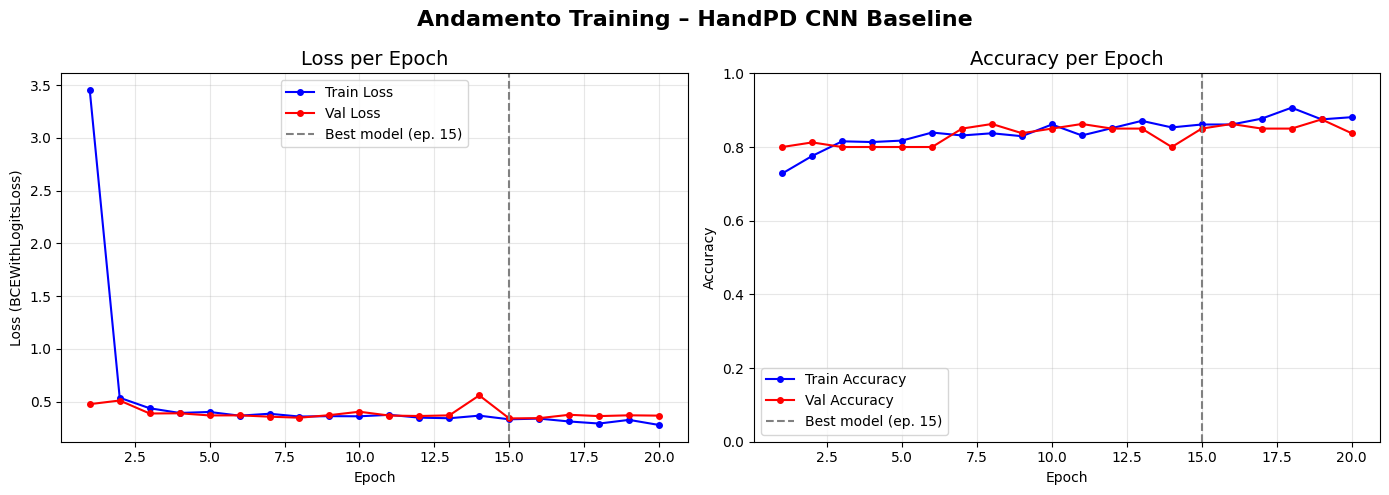

Grafico salvato in: /content/drive/MyDrive/HandPD_Dataset/training_curves.png


In [7]:
# ─────────────────────────────────────────────────────────────
# CELLA 6 – Plot Loss e Accuracy per Epoch
# ─────────────────────────────────────────────────────────────
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot Loss ────────────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', label=f'Best model (ep. {best_epoch})')
axes[0].set_title('Loss per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCEWithLogitsLoss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot Accuracy ────────────────────────────────────────────
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', markersize=4)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Accuracy',   markersize=4)
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', label=f'Best model (ep. {best_epoch})')
axes[1].set_title('Accuracy per Epoch', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Andamento Training – HandPD CNN Baseline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico salvato in: {os.path.join(BASE_DIR, 'training_curves.png')}")


   RISULTATI TEST SET (best model)
  Accuracy:  0.8553
  Precision: 0.8500
  Recall:    0.9917
  F1-Score:  0.9154


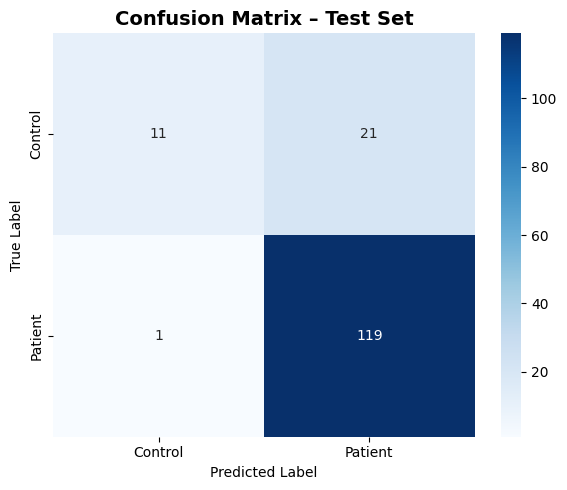

Confusion matrix salvata in: /content/drive/MyDrive/HandPD_Dataset/confusion_matrix.png


In [8]:
# ─────────────────────────────────────────────────────────────
# CELLA 7 – Valutazione sul Test Set (con best model)
# ─────────────────────────────────────────────────────────────

# Carichiamo i pesi del modello migliore salvato durante il training
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # FIX squeeze(): squeeze(1) per evitare collasso con batch singolo
        outputs = model(inputs).squeeze(1)

        preds = (torch.sigmoid(outputs) >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ── Metriche ─────────────────────────────────────────────────
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels,   all_preds, zero_division=0)
f1   = f1_score(all_labels,       all_preds, zero_division=0)

print("\n" + "="*40)
print("   RISULTATI TEST SET (best model)")
print("="*40)
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("="*40)

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Control', 'Patient'],
    yticklabels=['Control', 'Patient']
)
plt.title('Confusion Matrix – Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrix salvata in: {os.path.join(BASE_DIR, 'confusion_matrix.png')}")